In [ ]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_utils import load_quasar_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('style.mplstyle')

from scipy.stats import linregress

colors = {'u': 'tab:blue',
          'g': 'tab:green',
          'r': 'tab:orange',
          'i': 'tab:red',
          'z': 'tab:brown',
          'y': 'tab:gray'}

# Load AGN same length data
agn_samelength_df = load_quasar_data("results/data/aug25_stone_nobwb_poly1_samelength2400_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_samelength_df['object_id'] = agn_samelength_df['object_id'].astype(str)

# Load stone data
stone_df = pd.read_csv('data/aug8_stone_merged.csv')
stone_df['object_id'] = stone_df['object_id'].astype(str)

# Load standard data
agn_df = load_quasar_data("results/data/aug19_stone_nobwb_poly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))
merged_agn_samelength = pd.merge(agn_samelength_df, agn_df, on='object_id', how='inner', suffixes=('_samelength', '_agn'))


<unknown>:1193: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1207: SyntaxWarning: invalid escape sequence '\p'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 298.37it/s]


Number of quasars loaded: 180
Number of quasars with 0 < z <= 1.0: 31
Number of quasars with z > 3: 8
Highest redshift quasar: 4.1577668182859
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err', 'mags_mean_u', 'mags_mean_g']
Skipping data cuts as apply_cut is False.


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 295.78it/s]


Number of quasars loaded: 180
Number of quasars with 0 < z <= 1.0: 31
Number of quasars with z > 3: 8
Highest redshift quasar: 4.1577668182859
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err', 'width_blr_g', 'width_blr_g_err', 'width_blr_u', 'width_blr_u_err', 'mags_mean_u', 'mags_mean_g']
Skipping data cuts as apply_cut is False.


In [5]:
def plot_stone_vs_this_work(
    merged_df,
    sigma_keys,  # dict: {'x': str, 'y': str, 'xerr': str|tuple, 'yerr': str|tuple, 'xlabel': str, 'ylabel': str}
    tau_keys,    # dict: {'x': str, 'y': str, 'xerr': str|tuple, 'yerr': str|tuple, 'xlabel': str, 'ylabel': str}
    bands=('g', 'r', 'i'),
    figsize=(12, 7.6),
    band_colors=None,
    show=True,
    figfile='plots/appendix/stone.png'
):
    if band_colors is None:
        band_colors = {'g': 'tab:green', 'r': 'tab:red', 'i': 'tab:purple'}

    ncols = len(bands)
    fig, axes = plt.subplots(2, ncols, figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.01, wspace=0.0, hspace=0.02)

    axes = np.atleast_2d(axes)

    def _limits(x, y, pad=0.04):
        lo = np.nanmin([np.nanmin(x), np.nanmin(y)])
        hi = np.nanmax([np.nanmax(x), np.nanmax(y)])
        rng = max(hi - lo, 1e-6)
        return lo - pad * rng, hi + pad * rng

    def _style(ax):
        ax.tick_params(direction='in', which='both', top=True, right=True, length=3, pad=2)
        for s in ax.spines.values():
            s.set_linewidth(1.1)
        ax.legend(loc='upper left', frameon=True, fancybox=True, framealpha=1,
                  edgecolor='0.2', facecolor='white', fontsize=11)

    def _maybe_get(df, pattern, band):
        if pattern is None:
            return None
        if isinstance(pattern, tuple):
            lo = df[pattern[0].format(band=band)].to_numpy()
            up = df[pattern[1].format(band=band)].to_numpy()
            return (lo, up)
        return df[pattern.format(band=band)].to_numpy()

    def _extract_xyerr(df, keydict, band):
        x = df[keydict['x'].format(band=band)].to_numpy()
        y = df[keydict['y'].format(band=band)].to_numpy()
        xerr = _maybe_get(df, keydict.get('xerr'), band)
        yerr = _maybe_get(df, keydict.get('yerr'), band)

        m = np.isfinite(x) & np.isfinite(y)
        if isinstance(xerr, tuple):
            m &= np.isfinite(xerr[0]) & np.isfinite(xerr[1])
        elif xerr is not None:
            m &= np.isfinite(xerr)
        if isinstance(yerr, tuple):
            m &= np.isfinite(yerr[0]) & np.isfinite(yerr[1])
        elif yerr is not None:
            m &= np.isfinite(yerr)

        if m.sum() == 0:
            return None

        x, y = x[m], y[m]
        if isinstance(xerr, tuple):
            xerr = (xerr[0][m], xerr[1][m])
        elif xerr is not None:
            xerr = xerr[m]
        if isinstance(yerr, tuple):
            yerr = (yerr[0][m], yerr[1][m])
        elif yerr is not None:
            yerr = yerr[m]
        return x, y, xerr, yerr

    # ---------- Top row: σ ----------
    for ax, band in zip(axes[0], bands):
        data = _extract_xyerr(merged_df, sigma_keys, band)
        if data is None:
            ax.set_visible(False)
            continue
        x, y, xerr, yerr = data

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='0.35', alpha=0.28, lw=1.4, capsize=3, capthick=1, zorder=-9)
        ax.scatter(x, y, s=18, alpha=0.9, edgecolor='k', facecolor='k', linewidths=0.5, zorder=-8)

        xmin, xmax = _limits(x, y)
        line_color = band_colors.get(band, '0.2')
        ax.plot([xmin, xmax], [xmin, xmax], ls='--', lw=2.0, color=line_color,
                label=rf'$y=x$ ({band})', zorder=-4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(sigma_keys.get('xlabel').format(band=band), labelpad=1)
        ax.set_ylabel(sigma_keys.get('ylabel').format(band=band), labelpad=1)
        _style(ax)

    # ---------- Bottom row: τ ----------
    for ax, band in zip(axes[1], bands):
        data = _extract_xyerr(merged_df, tau_keys, band)
        if data is None:
            ax.set_visible(False)
            continue
        x, y, xerr, yerr = data

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='0.35', alpha=0.28, lw=1.4, capsize=3, capthick=1, zorder=-9)
        ax.scatter(x, y, s=18, alpha=0.9, edgecolor='k', facecolor='k', linewidths=0.5, zorder=-8)

        xmin, xmax = _limits(x, y)
        line_color = band_colors.get(band, '0.2')
        ax.plot([xmin, xmax], [xmin, xmax], ls='--', lw=2.0, color=line_color,
                label=rf'$y=x$ ({band})', zorder=-4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(tau_keys.get('xlabel').format(band=band), labelpad=1)
        ax.set_ylabel(tau_keys.get('ylabel').format(band=band), labelpad=1)
        _style(ax)

    for j in range(ncols):
        axes[0, j].tick_params(labelbottom=False)
    for i in range(2):
        for j in range(1, ncols):
            axes[i, j].tick_params(labelleft=False)

    fig.savefig(figfile, dpi=600)


    if show:
        plt.show()
    plt.close(fig)


In [ ]:
# Same Length Comparison
sigma_keys = {
    'x': 'log_sigma_band_{band}_agn',
    'y': 'log_sigma_band_{band}_samelength',
    'xerr': 'log_sigma_band_{band}_err_agn',
    'yerr': 'log_sigma_band_{band}_err_samelength',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (same RF length)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_tau_band_{band}_RF_agn',
    'y': 'log_tau_band_{band}_RF_samelength',
    'xerr': 'log_tau_band_{band}_RF_err_agn',
    'yerr': 'log_tau_band_{band}_RF_err_samelength',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (same RF length)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

plot_stone_vs_this_work(merged_agn_samelength, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_samelength_2400days.pdf")


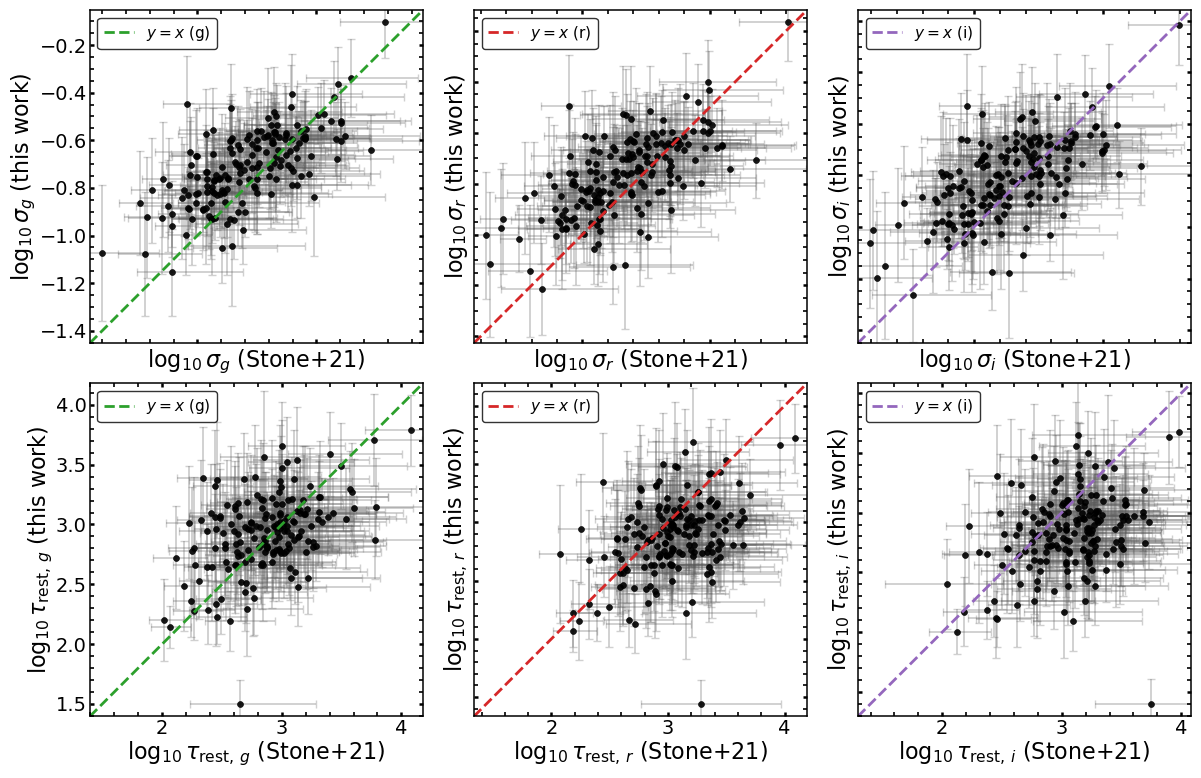

In [6]:
# Stone Comparison w/ poly1

sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_wpoly1.pdf")


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 290.14it/s]


Number of quasars loaded: 180
Number of quasars with 0 < z <= 1.0: 31
Number of quasars with z > 3: 8
Highest redshift quasar: 4.1577668182859
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err', 'mags_mean_u', 'mags_mean_g']
Skipping data cuts as apply_cut is False.


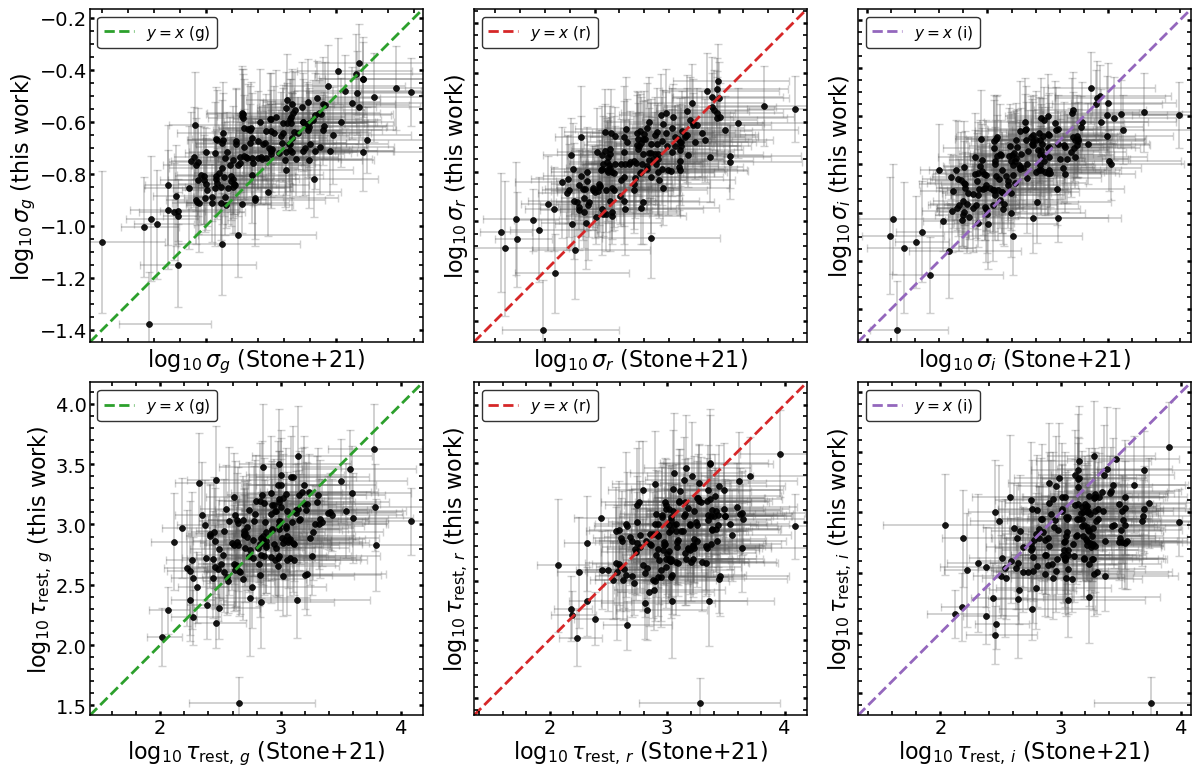

In [18]:
# Stone Comparison wo/ poly1

sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

# Load standard data
agn_df = load_quasar_data("results/data/aug19_stone_nobwb_nopoly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))


plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_wopoly1.pdf")


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 313.49it/s]


Number of quasars loaded: 180
Number of quasars with 0 < z <= 1.0: 31
Number of quasars with z > 3: 8
Highest redshift quasar: 4.1577668182859
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err', 'mags_mean_u', 'mags_mean_g']
Skipping data cuts as apply_cut is False.


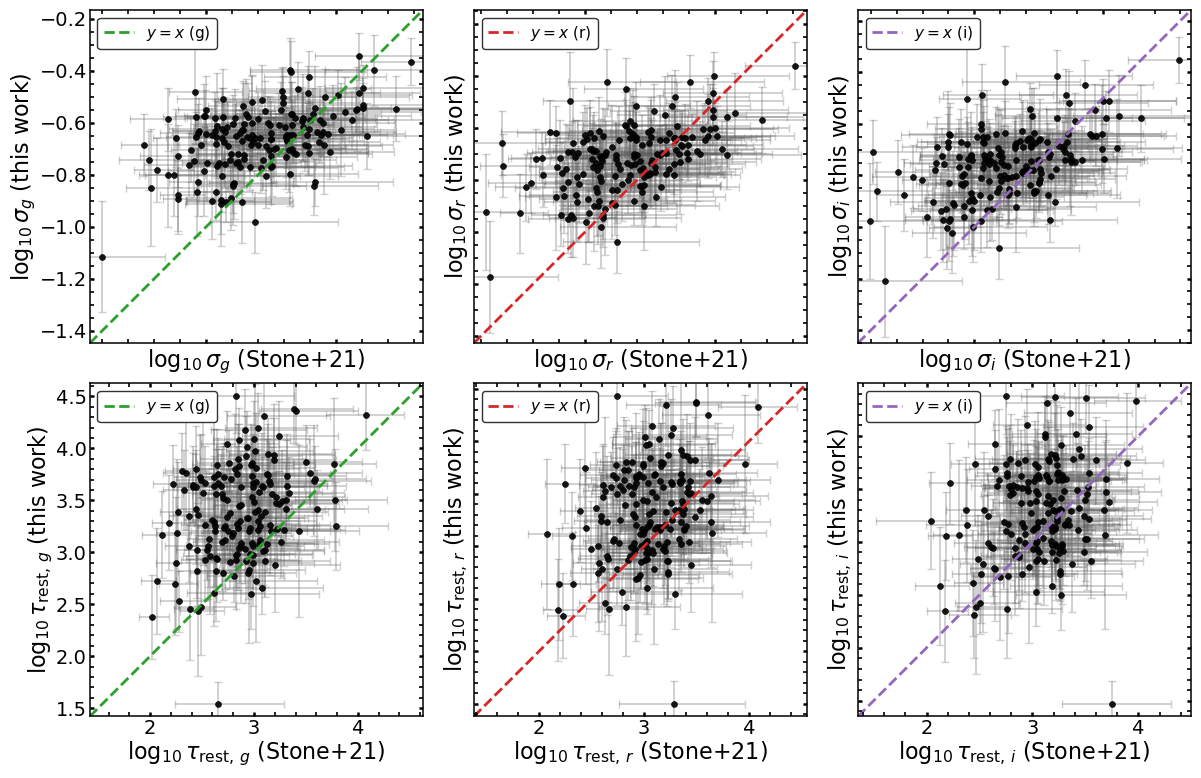

In [19]:
# Stone Comparison wo/ poly1 w/ bwb

sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

# Load standard data
agn_df = load_quasar_data("results/data/aug20_stone_bwb_nopoly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))


plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_bwb_wopoly1.pdf")


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 310.74it/s]
/tmp/ipykernel_959447/4034639757.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agn_df[f'log_sigma_band_{band}_eq'] = np.log10(sigma_eq)
/tmp/ipykernel_959447/4034639757.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agn_df[f'log_tau_band_{band}_RF_eq'] = np.log10(tau_eq)
/tmp/ipykernel_959447/4034639757.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

Number of quasars loaded: 180
Number of quasars with 0 < z <= 1.0: 31
Number of quasars with z > 3: 8
Highest redshift quasar: 4.1577668182859
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err', 'mags_mean_u', 'mags_mean_g']
Skipping data cuts as apply_cut is False.


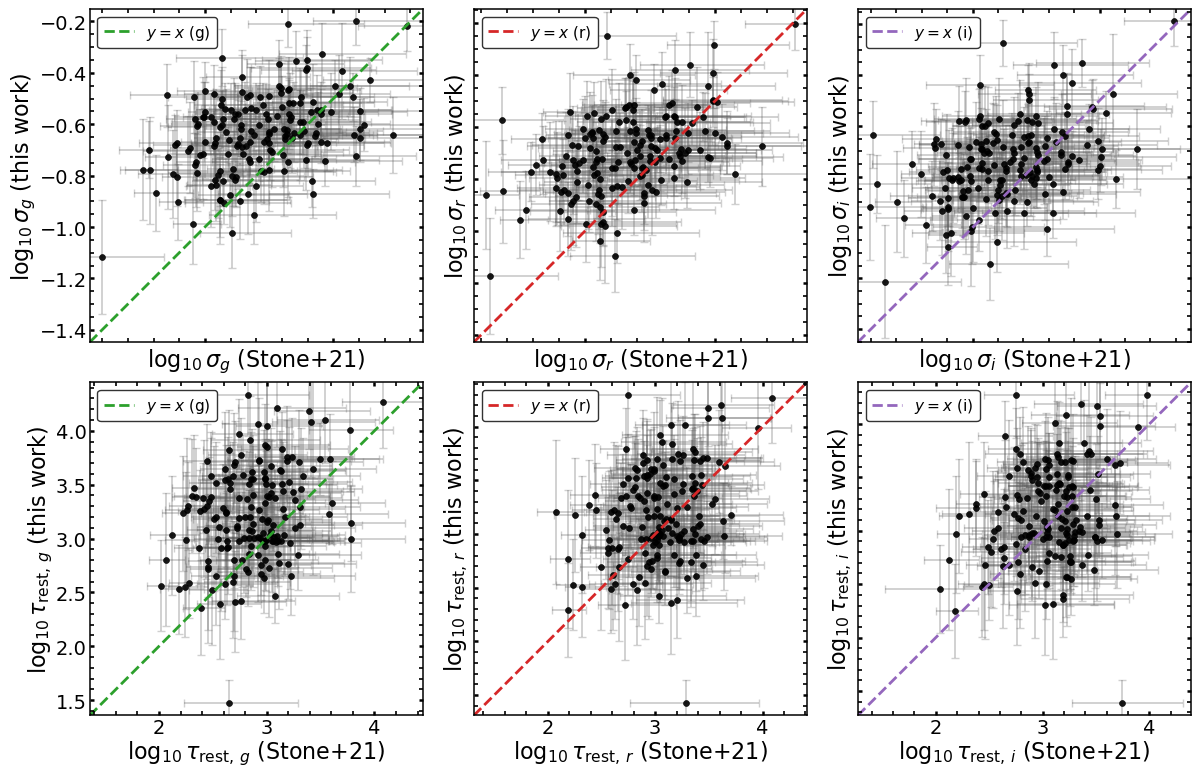

In [22]:
# Stone Comparison bwb, no poly1

def drw_equiv(amp_cont, tau_drw, bwb_alpha, bwb_beta):
    A = amp_cont
    q2 = (bwb_alpha * A**2)**2  # q_b^2

    sigma2_eq = A**2 + 2.0 * q2
    tau_eq = tau_drw * (A**2 + (2.0/bwb_beta)*q2) / (A**2 + 2.0*q2)
    return np.sqrt(sigma2_eq), tau_eq

agn_df = load_quasar_data("results/data/aug20_stone_bwb_poly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)


for band in ('g','r','i'):
    sigma = 10**agn_df[f'log_sigma_band_{band}']
    tau = 10**agn_df[f'log_tau_band_{band}_RF']
    sigma_eq, tau_eq = drw_equiv(sigma, tau, bwb_alpha=agn_df['bwb_alpha'], bwb_beta=agn_df['bwb_beta'])
    agn_df[f'log_sigma_band_{band}_eq'] = np.log10(sigma_eq)
    agn_df[f'log_tau_band_{band}_RF_eq'] = np.log10(tau_eq)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))

sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}_eq',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF_eq',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_bwb_poly1.pdf")
